In [1]:
from shap_rscu import load_and_preprocess_data, analyze_codon_shap_trends, codon_trajectory_plot_grid, \
compute_rscu_shap_correlations, get_codon_type, volcano_plot_grid, codon_category_map
import pandas as pd
from pandas.testing import assert_index_equal

In [2]:
segments=["01_PB2", "02_PB1", "03_PA", "04_HA", "05_NP", "06_NA", "07_MP", "08_NS"]

Processing segment 01_PB2
(14980, 65) (14980, 65)
Processing segment 02_PB1
(14962, 65) (14962, 65)
Processing segment 03_PA
(14948, 65) (14948, 65)
Processing segment 04_HA
(22745, 65) (22745, 65)
Processing segment 05_NP
(13603, 65) (13603, 65)
Processing segment 06_NA
(16492, 65) (16492, 65)
Processing segment 07_MP
(12247, 65) (12247, 65)
Processing segment 08_NS
(12799, 65) (12799, 65)
[('01_PB2', 'Avian'), ('01_PB2', 'Non-human Mammal'), ('01_PB2', 'Human'), ('02_PB1', 'Avian'), ('02_PB1', 'Non-human Mammal'), ('02_PB1', 'Human'), ('03_PA', 'Avian'), ('03_PA', 'Non-human Mammal'), ('03_PA', 'Human'), ('04_HA', 'Avian'), ('04_HA', 'Non-human Mammal'), ('04_HA', 'Human'), ('05_NP', 'Avian'), ('05_NP', 'Non-human Mammal'), ('05_NP', 'Human'), ('06_NA', 'Avian'), ('06_NA', 'Non-human Mammal'), ('06_NA', 'Human'), ('07_MP', 'Avian'), ('07_MP', 'Non-human Mammal'), ('07_MP', 'Human'), ('08_NS', 'Avian'), ('08_NS', 'Non-human Mammal'), ('08_NS', 'Human')]
0 01_PB2 Avian
1 01_PB2 Non-hum

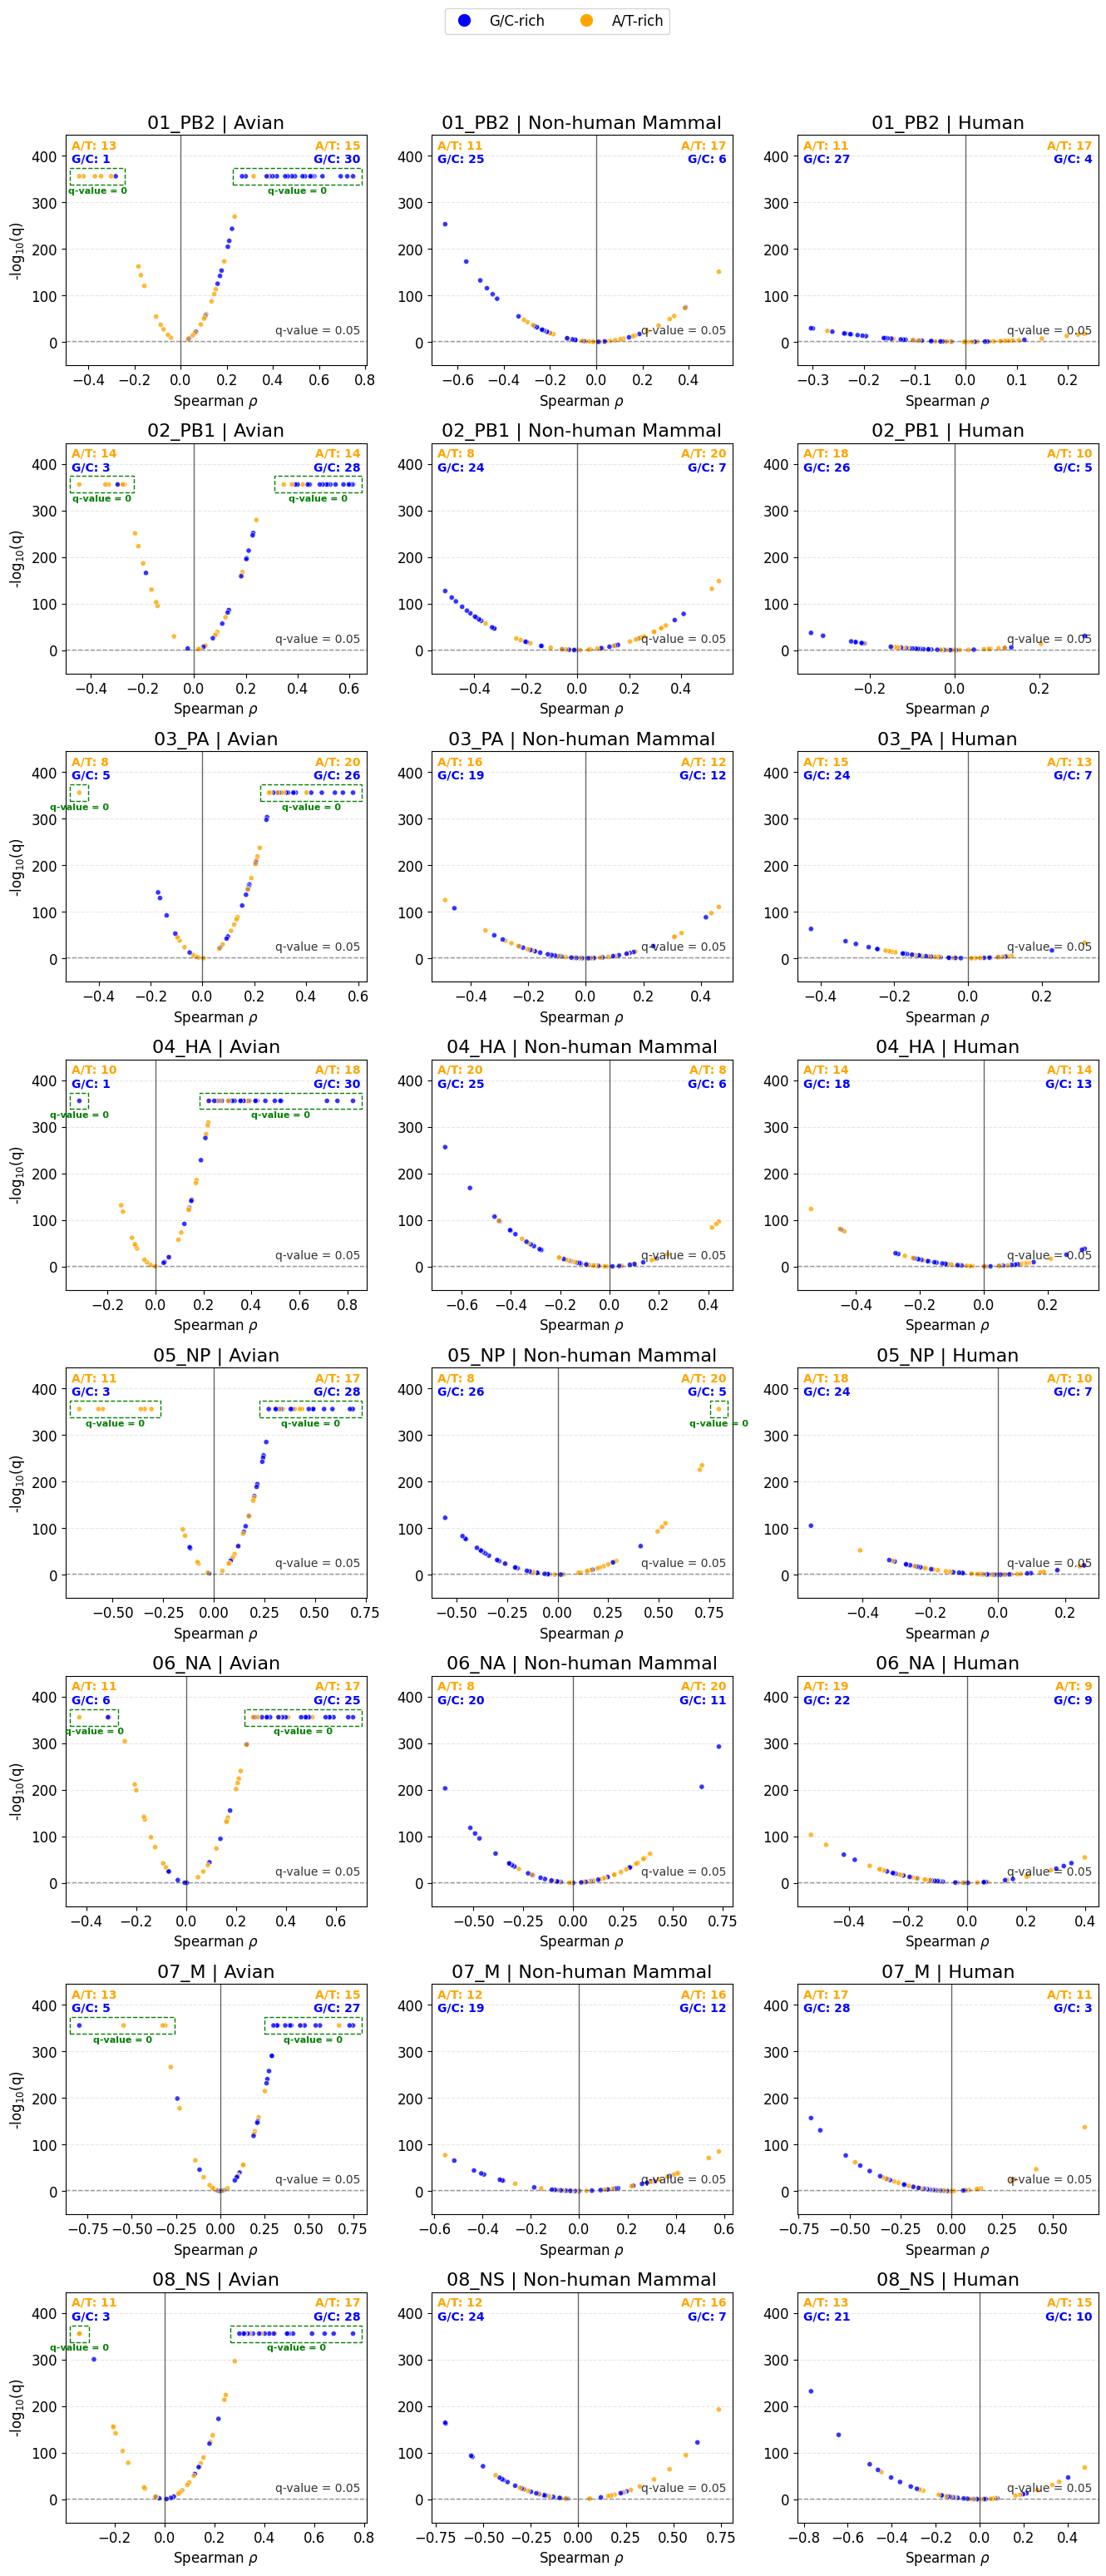

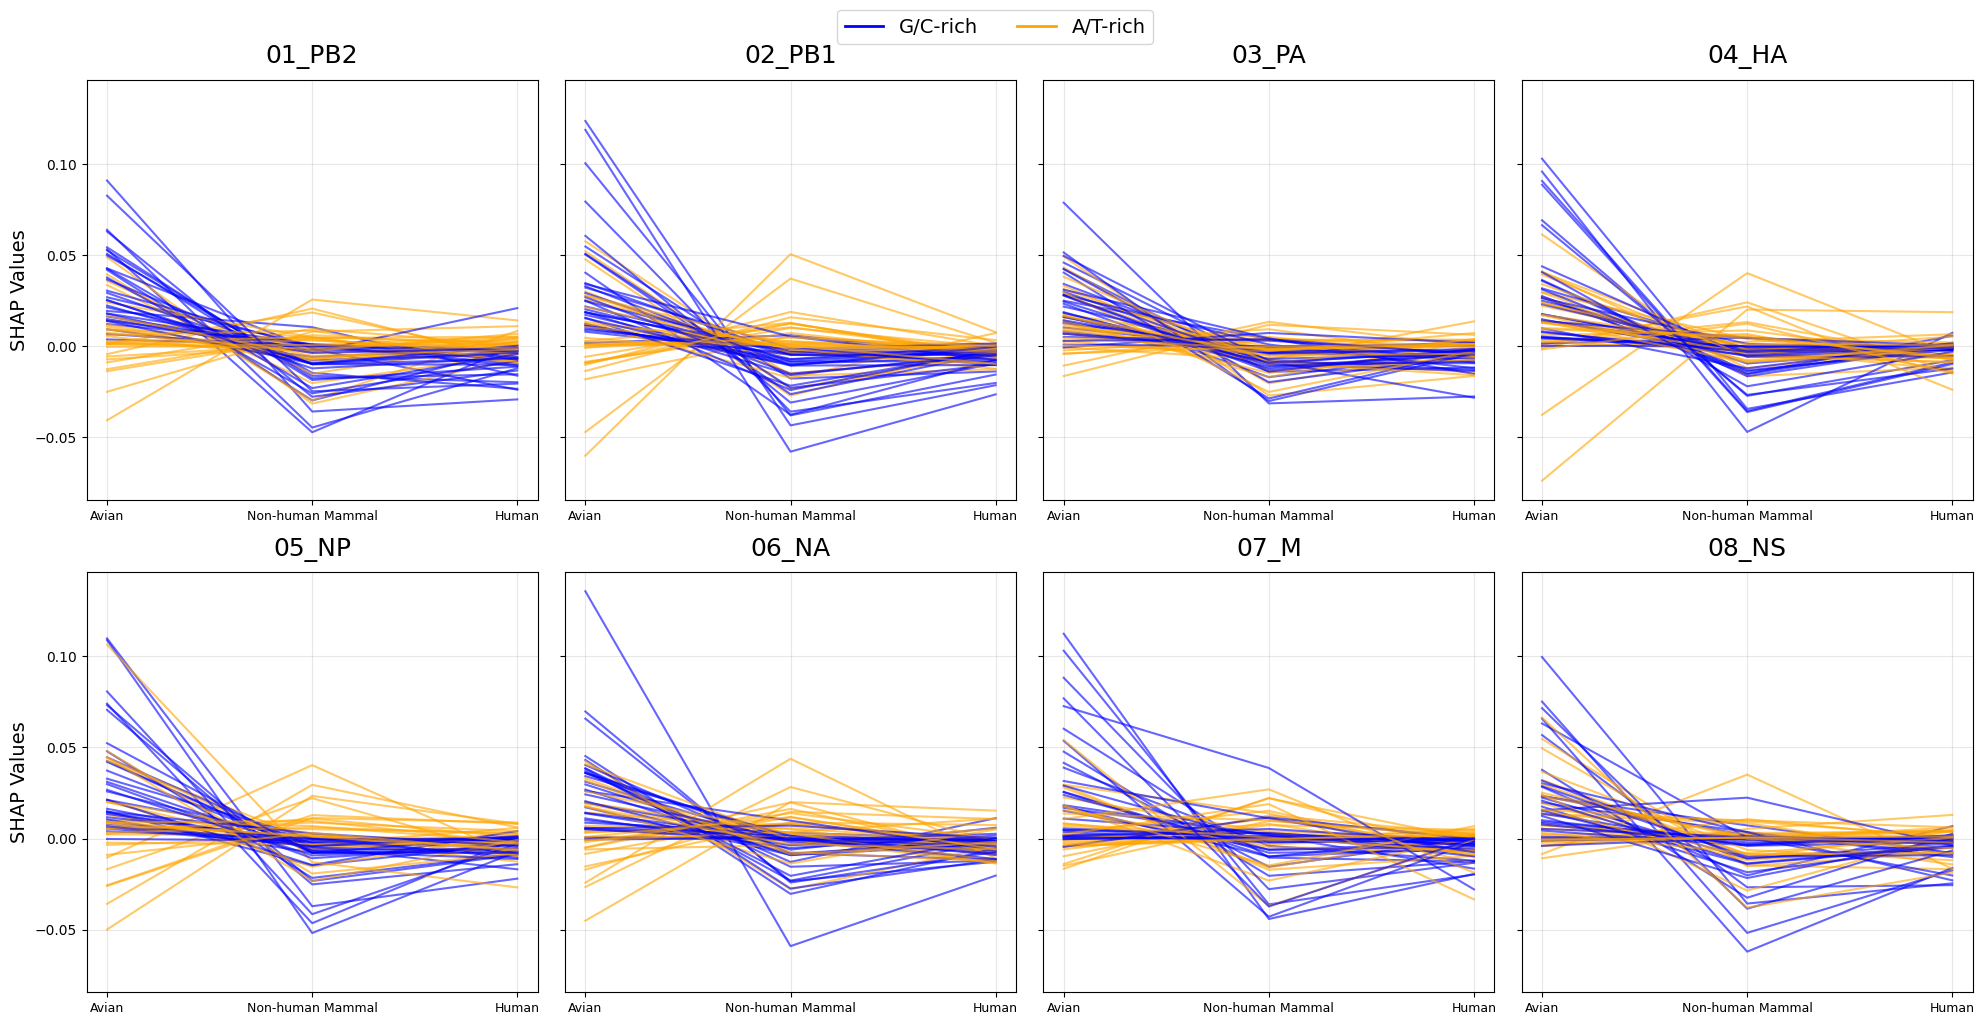

In [3]:
corr_dfs = {}
trend_dfs = {}
for seg in segments:
    print("="*50)
    print(f"Processing segment {seg}")
    print("="*50)
    
    shap_df_post2020, rscu_df_post2020, codon_cols  = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Post2020_', file_pattern_rscu ='All_True_Label_Post2020_', datatype= 'post2020', verbose=False)
    shap_df_pre2020,  rscu_df_pre2020, _            = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Training_', file_pattern_rscu ='All_True_Label_Training_', datatype= 'pre2020', verbose=False)
    shap_df_H5Nx, rscu_df_H5Nx, _                   = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5/H5Nx_Codon_Shap', file_pattern_shap ='H5Nx_', file_pattern_rscu ='H5Nx_', datatype= 'post2020', verbose=False)
    shap_df = pd.concat([shap_df_pre2020, shap_df_post2020], ignore_index=True)
    rscu_df = pd.concat([rscu_df_pre2020, rscu_df_post2020], ignore_index=True)
    codon_categories = codon_category_map(codon_cols)
    
    codon_categories = codon_category_map(codon_cols)
    shap_df_subtype = shap_df[shap_df['subtype'].astype(str).isin(['H9N2', 'H7N9', 'H5N1', 'H5N6'])]
    rscu_df_subtype = rscu_df[rscu_df['subtype'].astype(str).isin(['H9N2', 'H7N9', 'H5N1', 'H5N6'])]
    print (shap_df_subtype.shape, rscu_df_subtype.shape)
    
    assert_index_equal(shap_df_subtype.columns, shap_df_H5Nx.columns)
    assert_index_equal(rscu_df_subtype.columns, rscu_df_H5Nx.columns)

    shap_df_subtype_combined = pd.concat([shap_df_subtype, shap_df_H5Nx], ignore_index=True)
    rscu_df_subtype_combined = pd.concat([rscu_df_subtype, rscu_df_H5Nx], ignore_index=True)
    
    corr_df = compute_rscu_shap_correlations(shap_df_subtype_combined, rscu_df_subtype_combined, codon_cols, codon_categories, method='spearman')
    corr_dfs[seg]= corr_df
    trend_df = analyze_codon_shap_trends(shap_df_subtype_combined, codon_cols, codon_categories)
    trend_dfs[seg] = trend_df
volcano_plot_grid(corr_dfs, codon_categories, save_path=f"../../results/Other_Figs/rscu_shap_Correlation_spearman_purely_avian_origin.png", grid_shape=(8, 3))
codon_trajectory_plot_grid(trend_dfs, codon_categories, save_path=f"../../results/Figure_7_Trajectories_Pure_Avian.png")

Processing segment 01_PB2
(126799, 65) (126799, 65)
Processing segment 02_PB1
(119378, 65) (119378, 65)
Processing segment 03_PA
(128224, 65) (128224, 65)
Processing segment 04_HA
(202396, 65) (202396, 65)
Processing segment 05_NP
(100495, 65) (100495, 65)
Processing segment 06_NA
(169593, 65) (169593, 65)
Processing segment 07_MP
(80780, 65) (80780, 65)
Processing segment 08_NS
(75731, 65) (75731, 65)
[('01_PB2', 'Avian'), ('01_PB2', 'Non-human Mammal'), ('01_PB2', 'Human'), ('02_PB1', 'Avian'), ('02_PB1', 'Non-human Mammal'), ('02_PB1', 'Human'), ('03_PA', 'Avian'), ('03_PA', 'Non-human Mammal'), ('03_PA', 'Human'), ('04_HA', 'Avian'), ('04_HA', 'Non-human Mammal'), ('04_HA', 'Human'), ('05_NP', 'Avian'), ('05_NP', 'Non-human Mammal'), ('05_NP', 'Human'), ('06_NA', 'Avian'), ('06_NA', 'Non-human Mammal'), ('06_NA', 'Human'), ('07_MP', 'Avian'), ('07_MP', 'Non-human Mammal'), ('07_MP', 'Human'), ('08_NS', 'Avian'), ('08_NS', 'Non-human Mammal'), ('08_NS', 'Human')]
0 01_PB2 Avian
1 01

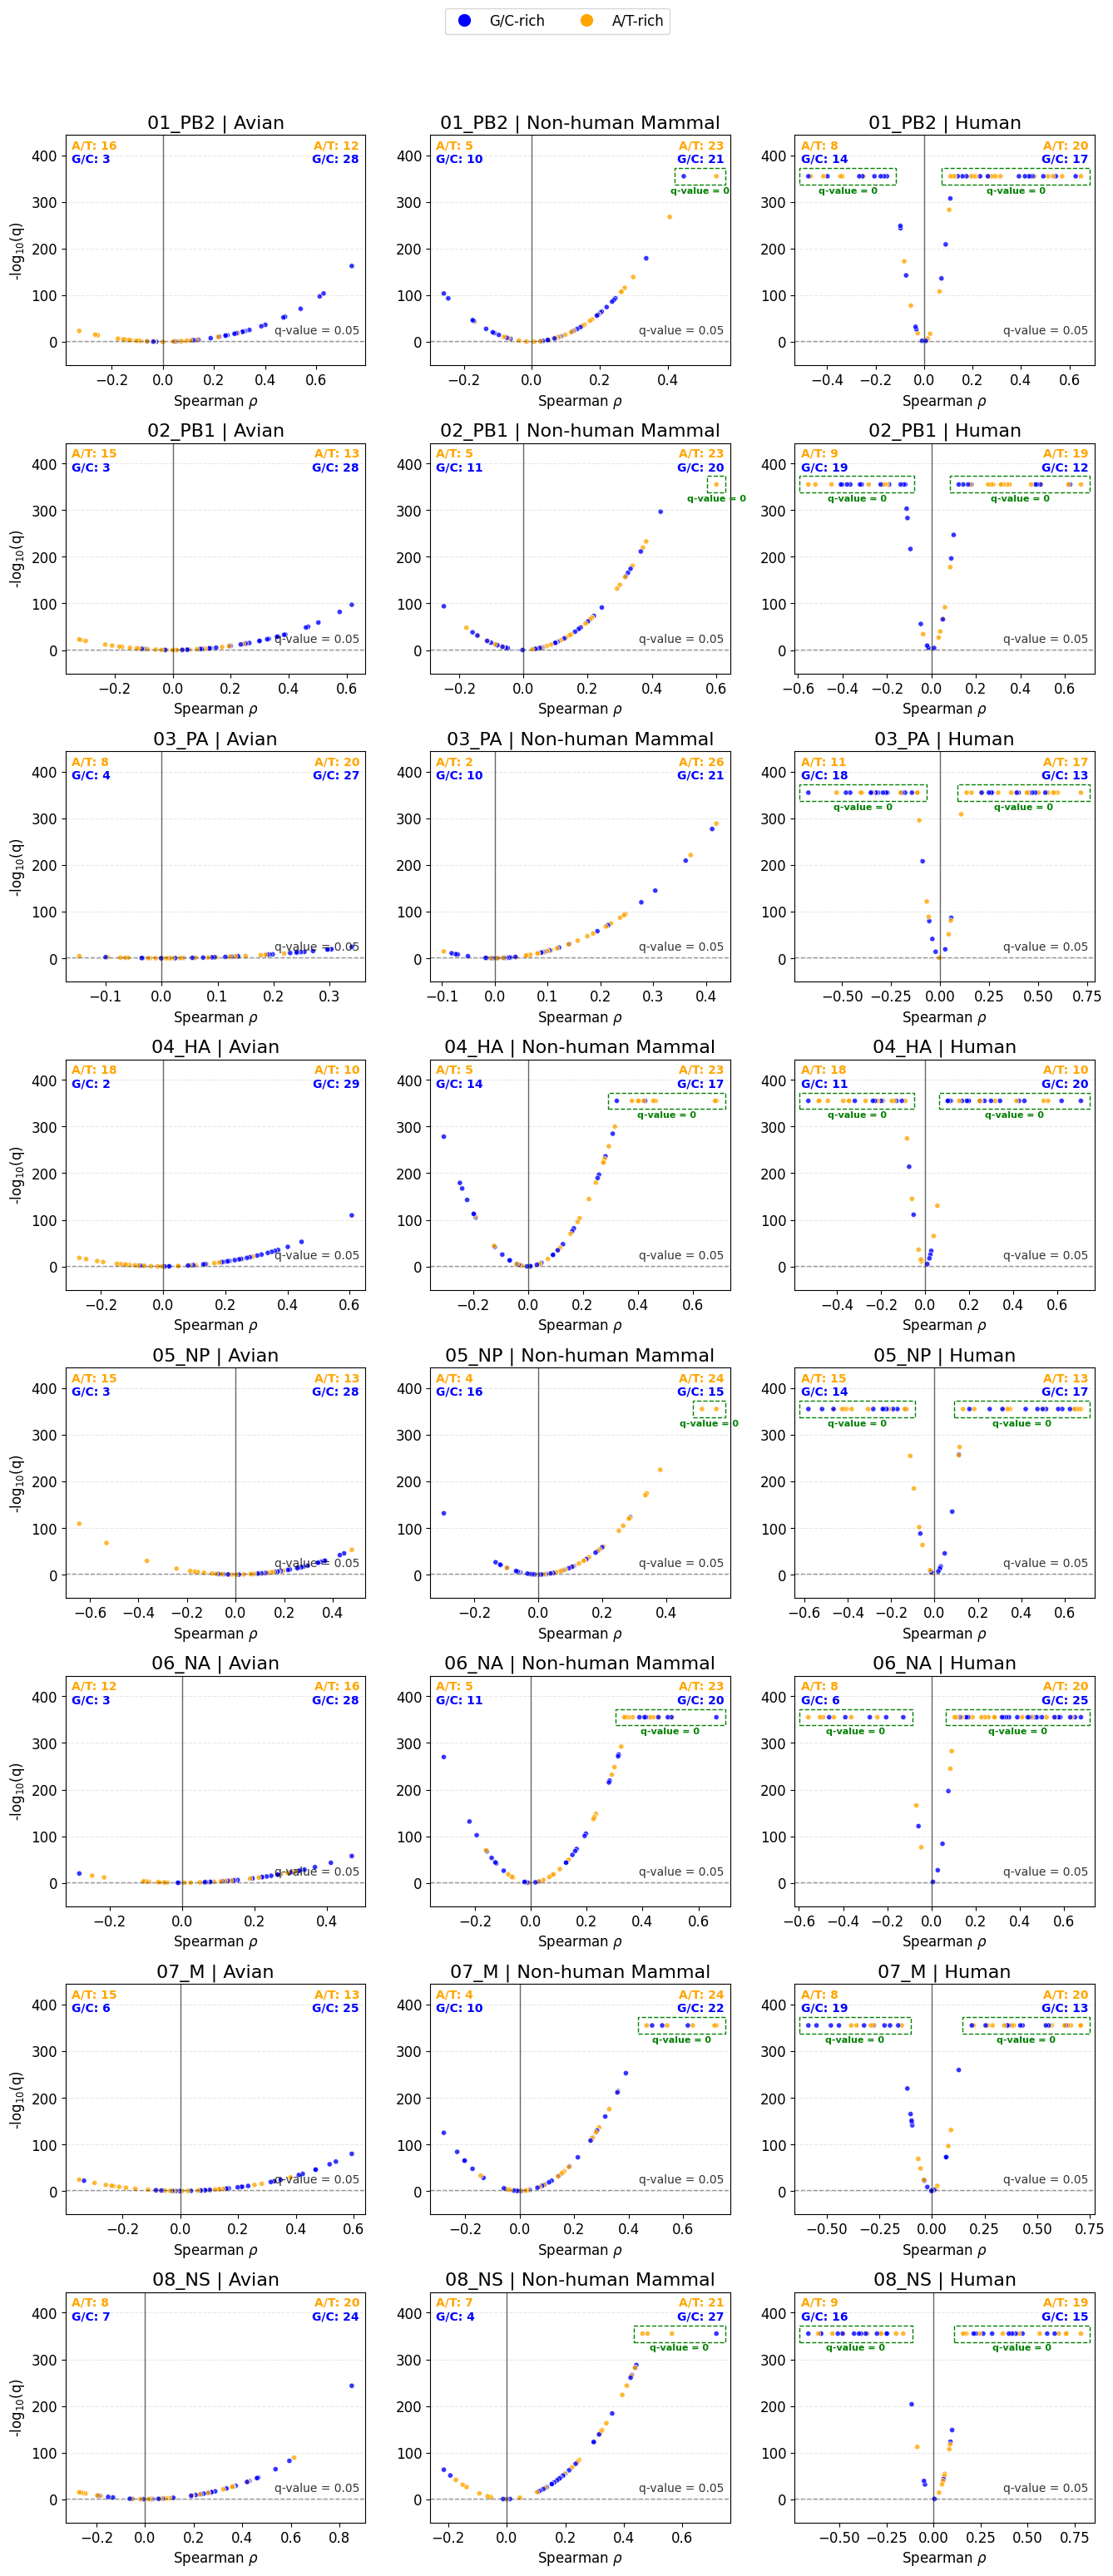

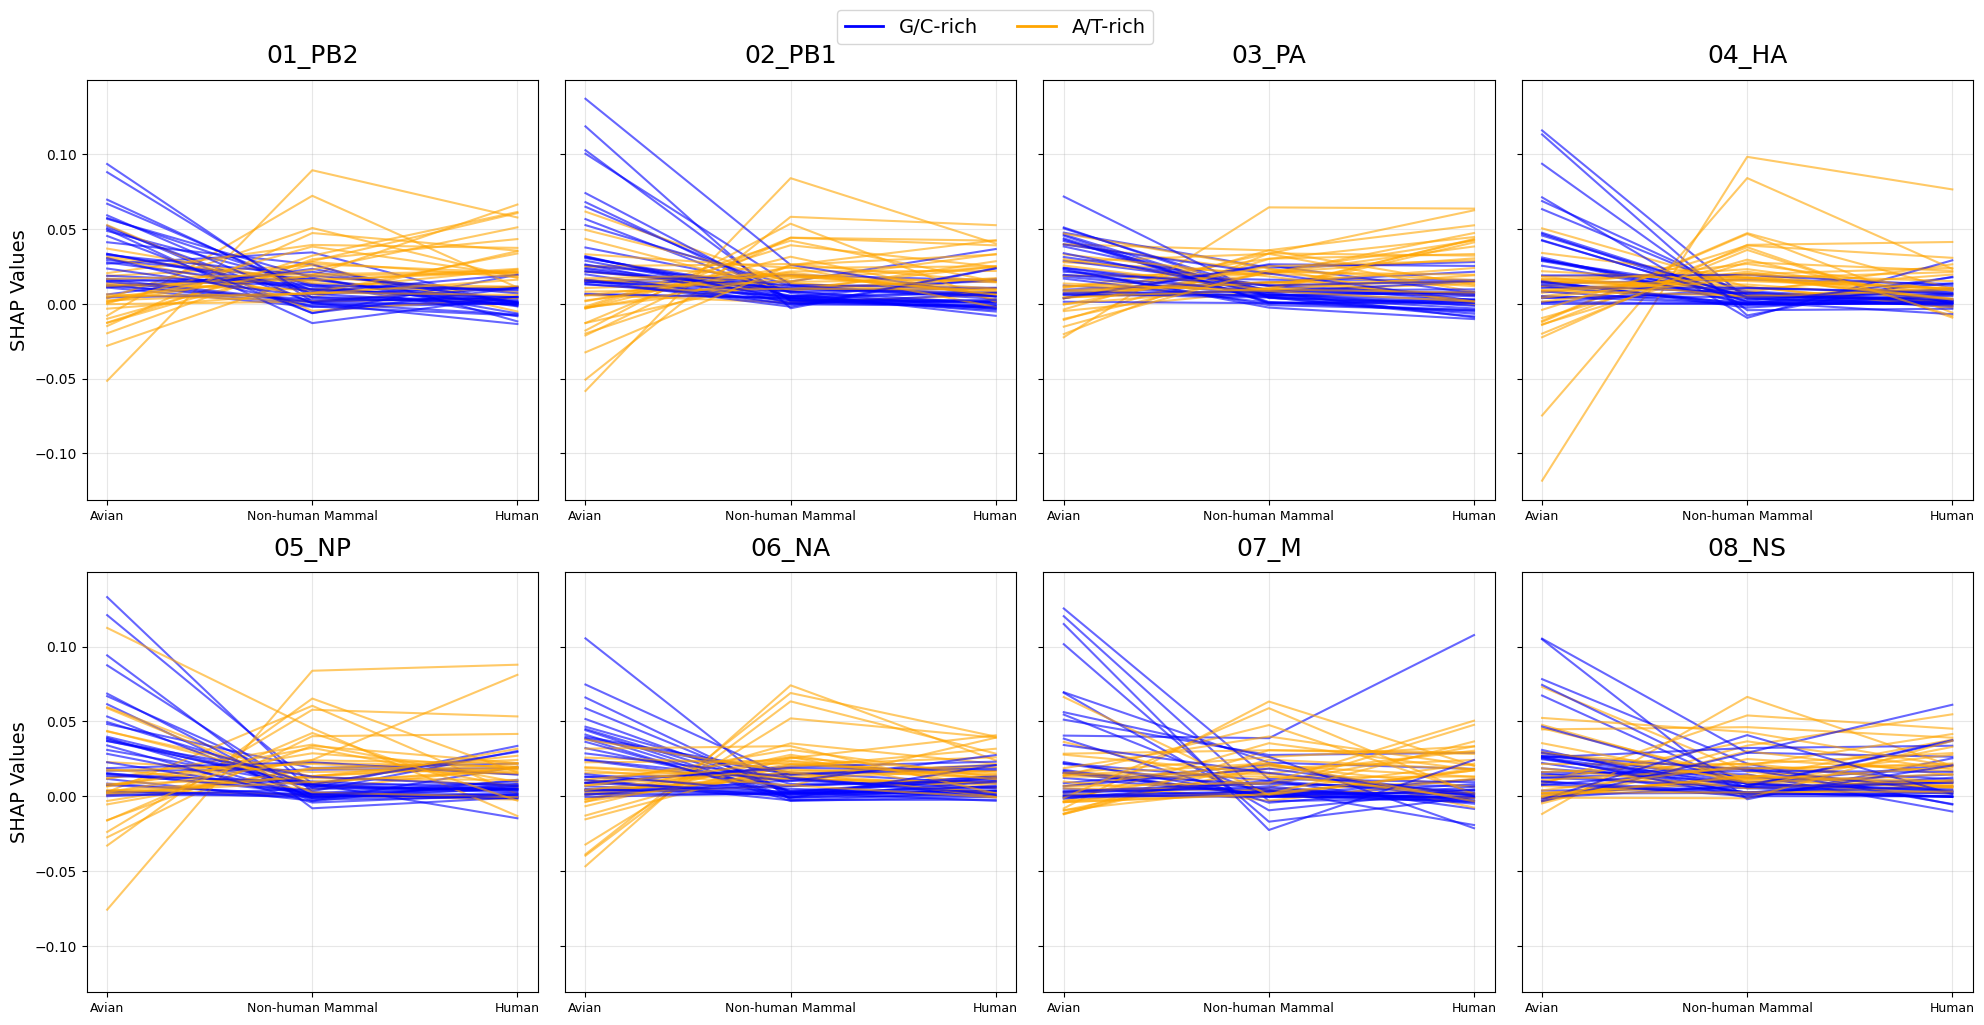

In [4]:
corr_dfs = {}
trend_dfs = {}
for seg in segments:
    print("="*50)
    print(f"Processing segment {seg}")
    print("="*50)
    
    shap_df_post2020, rscu_df_post2020, codon_cols  = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Post2020_', file_pattern_rscu ='All_True_Label_Post2020_', datatype= 'post2020', verbose=False)
    shap_df_pre2020,  rscu_df_pre2020, _            = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Training_', file_pattern_rscu ='All_True_Label_Training_', datatype= 'pre2020', verbose=False)
    shap_df = pd.concat([shap_df_pre2020, shap_df_post2020], ignore_index=True)
    rscu_df = pd.concat([rscu_df_pre2020, rscu_df_post2020], ignore_index=True)
    codon_categories = codon_category_map(codon_cols)
    
    codon_categories = codon_category_map(codon_cols)
    shap_df_subtype = shap_df[shap_df['subtype'].astype(str).isin(['H1N1', 'H3N2'])]
    rscu_df_subtype = rscu_df[rscu_df['subtype'].astype(str).isin(['H1N1', 'H3N2'])]
    print (shap_df_subtype.shape, rscu_df_subtype.shape)
    corr_df = compute_rscu_shap_correlations(shap_df_subtype, rscu_df_subtype, codon_cols, codon_categories, method='spearman')
    corr_dfs[seg]= corr_df
    trend_df = analyze_codon_shap_trends(shap_df_subtype, codon_cols, codon_categories)
    trend_dfs[seg] = trend_df
volcano_plot_grid(corr_dfs, codon_categories, save_path=f"../../results/Other_Figs/rscu_shap_Correlation_spearman_H1N1_H3N2.png", grid_shape=(8, 3))
codon_trajectory_plot_grid(trend_dfs, codon_categories, save_path=f"../../results/Supplementary_Figure_S9_Trajectories_H1N1_H3N2.png")

Processing segment 01_PB2
(3330, 65) (3330, 65)
Processing segment 02_PB1
(3289, 65) (3289, 65)
Processing segment 03_PA
(3386, 65) (3386, 65)
Processing segment 04_HA
(6534, 65) (6534, 65)
Processing segment 05_NP
(3239, 65) (3239, 65)
Processing segment 06_NA
(6174, 65) (6174, 65)
Processing segment 07_MP
(3723, 65) (3723, 65)
Processing segment 08_NS
(3062, 65) (3062, 65)
[('01_PB2', 'Avian'), ('01_PB2', 'Non-human Mammal'), ('01_PB2', 'Human'), ('02_PB1', 'Avian'), ('02_PB1', 'Non-human Mammal'), ('02_PB1', 'Human'), ('03_PA', 'Avian'), ('03_PA', 'Non-human Mammal'), ('03_PA', 'Human'), ('04_HA', 'Avian'), ('04_HA', 'Non-human Mammal'), ('04_HA', 'Human'), ('05_NP', 'Avian'), ('05_NP', 'Non-human Mammal'), ('05_NP', 'Human'), ('06_NA', 'Avian'), ('06_NA', 'Non-human Mammal'), ('06_NA', 'Human'), ('07_MP', 'Avian'), ('07_MP', 'Non-human Mammal'), ('07_MP', 'Human'), ('08_NS', 'Avian'), ('08_NS', 'Non-human Mammal'), ('08_NS', 'Human')]
0 01_PB2 Avian
1 01_PB2 Non-human Mammal
2 01_P

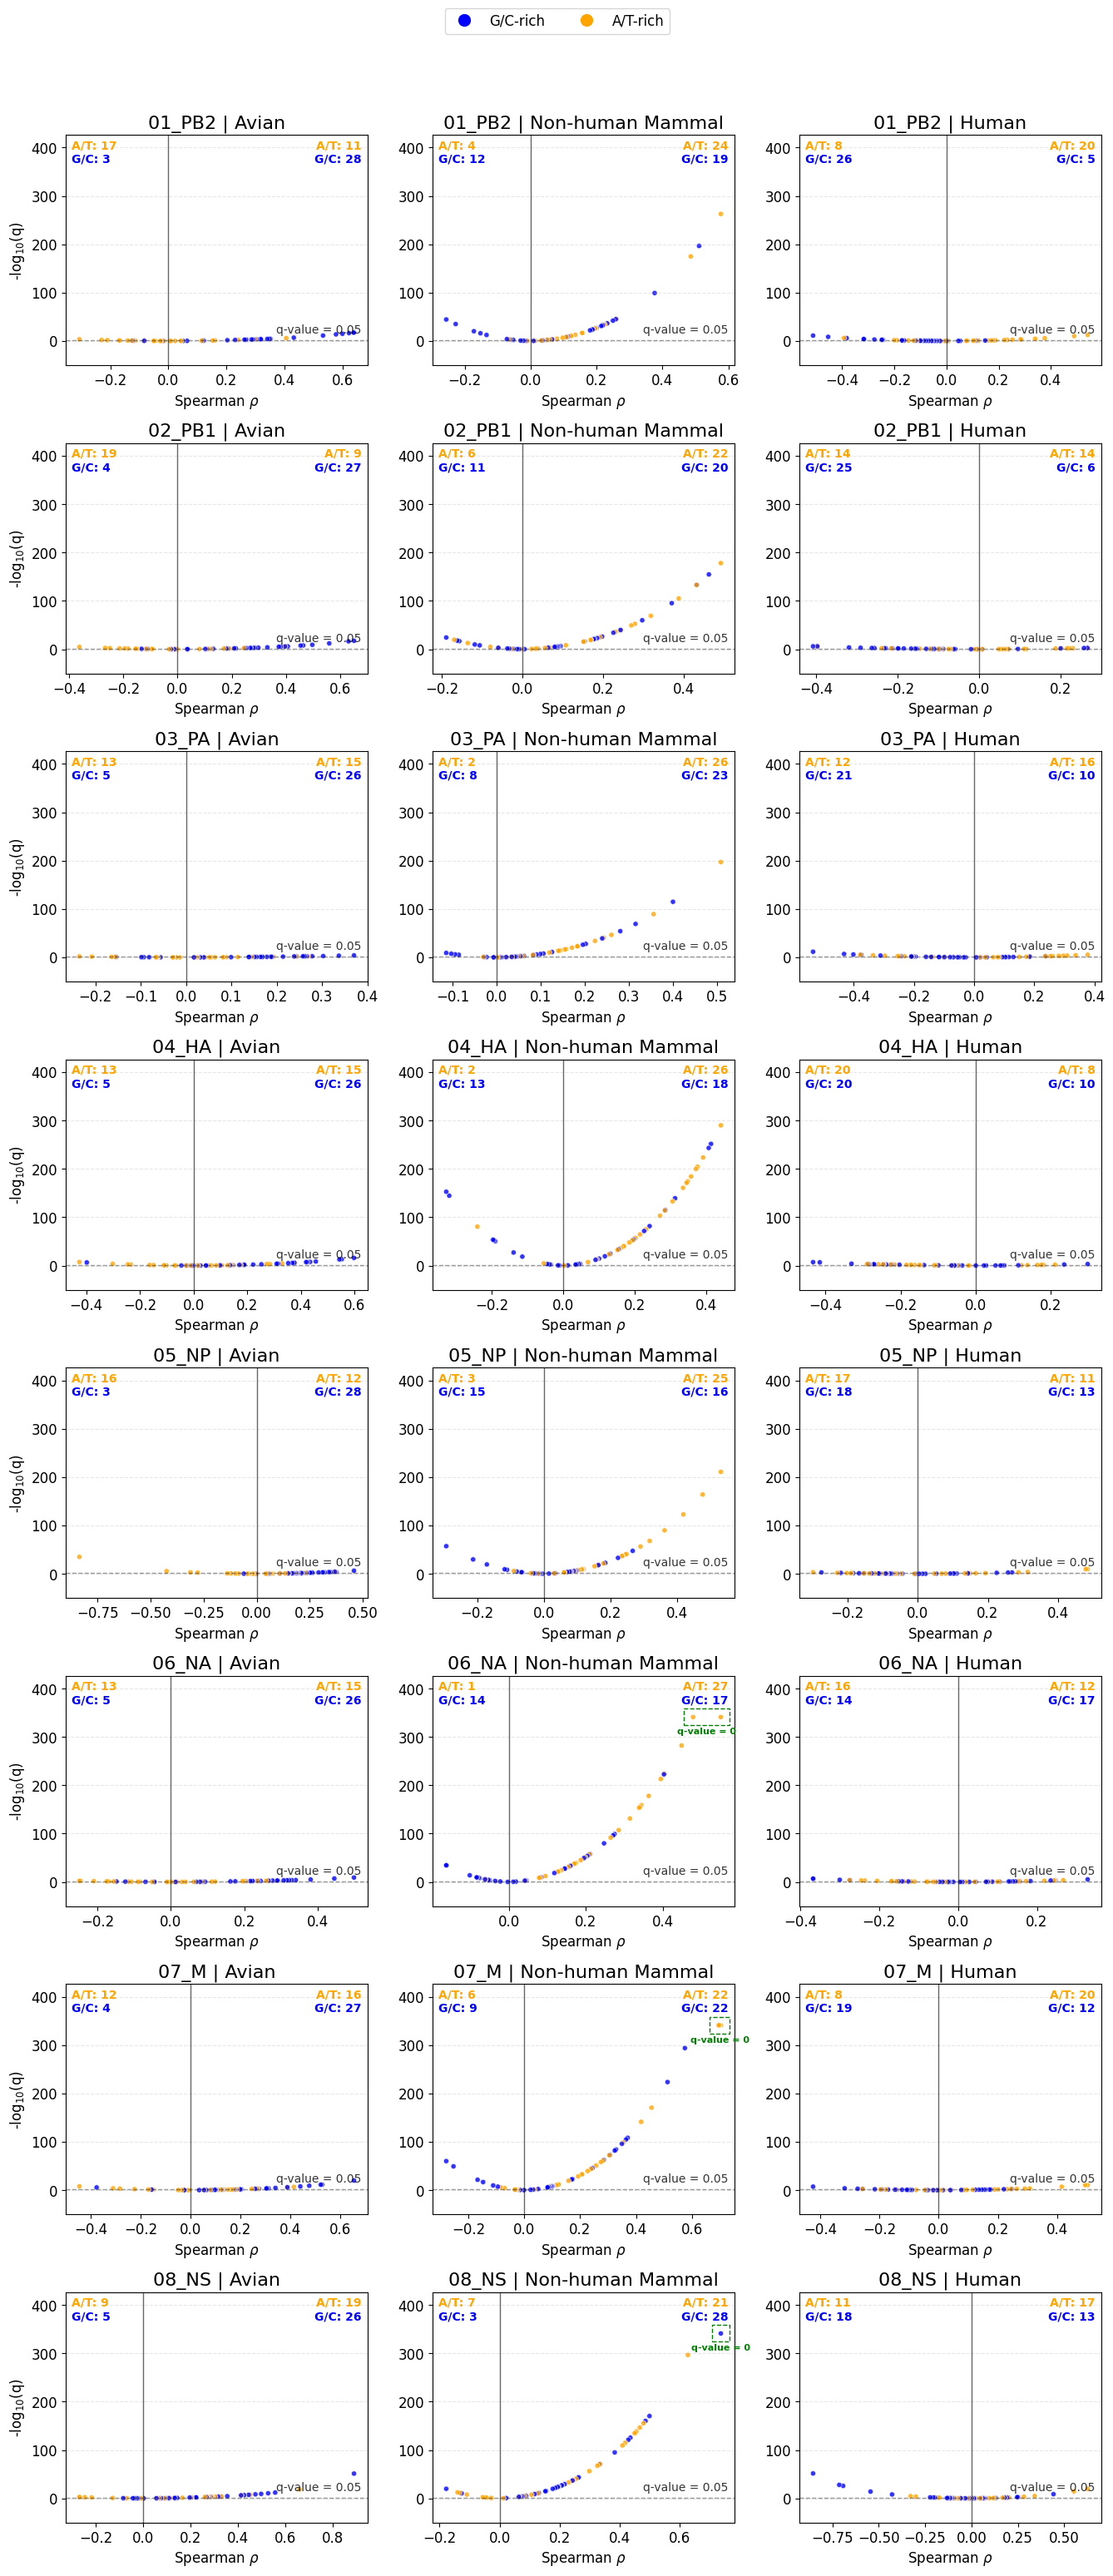

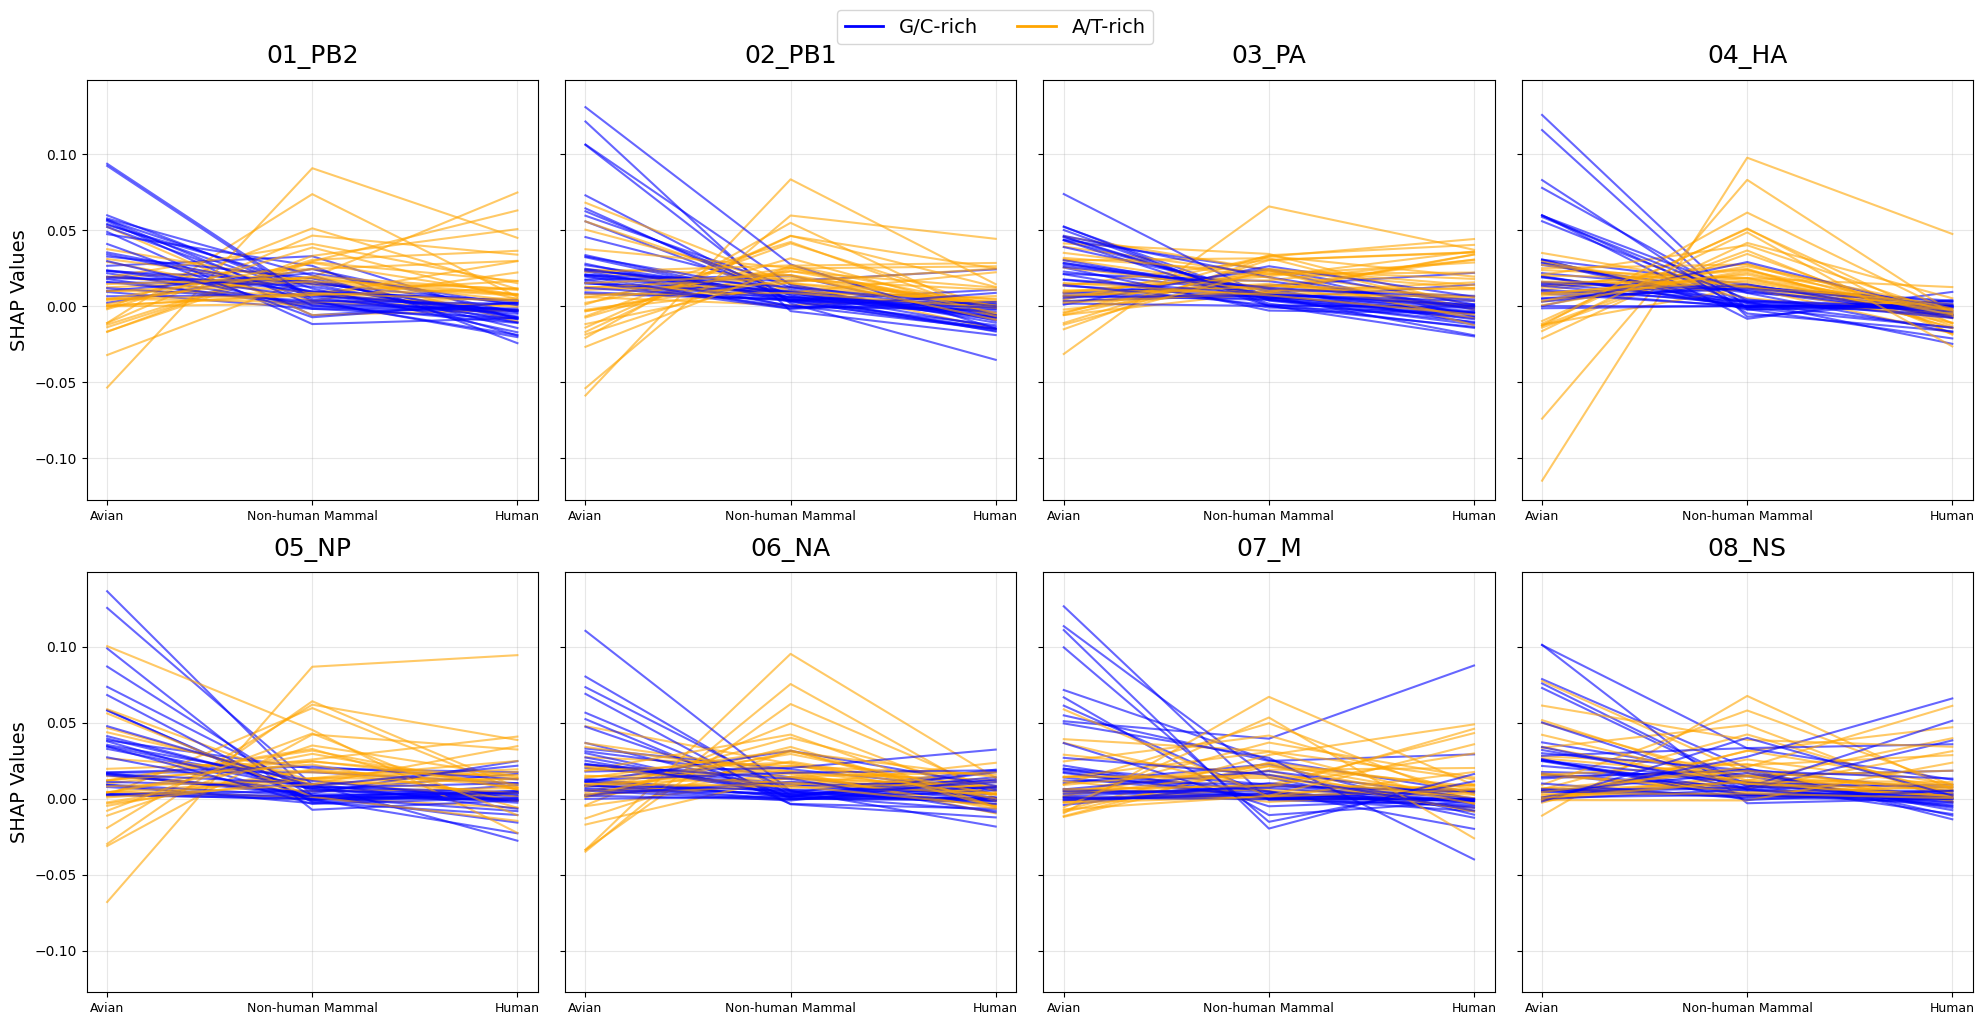

In [5]:
corr_dfs = {}
trend_dfs = {}
for seg in segments:
    print("="*50)
    print(f"Processing segment {seg}")
    print("="*50)
    
    shap_df_post2020, rscu_df_post2020, codon_cols  = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Post2020_', file_pattern_rscu ='All_True_Label_Post2020_', datatype= 'post2020', verbose=False)
    shap_df_pre2020,  rscu_df_pre2020, _            = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Training_', file_pattern_rscu ='All_True_Label_Training_', datatype= 'pre2020', verbose=False)
    shap_df = pd.concat([shap_df_pre2020, shap_df_post2020], ignore_index=True)
    rscu_df = pd.concat([rscu_df_pre2020, rscu_df_post2020], ignore_index=True)
    codon_categories = codon_category_map(codon_cols)
    
    codon_categories = codon_category_map(codon_cols)
    shap_df_subtype = shap_df[shap_df['subtype'].astype(str).isin(['H1N2', 'H2N2'])]
    rscu_df_subtype = rscu_df[rscu_df['subtype'].astype(str).isin(['H1N2', 'H2N2'])]
    print (shap_df_subtype.shape, rscu_df_subtype.shape)
    corr_df = compute_rscu_shap_correlations(shap_df_subtype, rscu_df_subtype, codon_cols, codon_categories, method='spearman')
    corr_dfs[seg]= corr_df
    trend_df = analyze_codon_shap_trends(shap_df_subtype, codon_cols, codon_categories)
    trend_dfs[seg] = trend_df
volcano_plot_grid(corr_dfs, codon_categories, save_path=f"../../results/Other_Figs/rscu_shap_Correlation_spearman_H1N2_H2N2.png", grid_shape=(8, 3))
codon_trajectory_plot_grid(trend_dfs, codon_categories, save_path=f"../../results/Supplementary_Figure_S10_Trajectories_H1N2_H2N2.png")

Processing segment 01_PB2
(2213, 65) (2213, 65)
Processing segment 02_PB1
(2117, 65) (2117, 65)
Processing segment 03_PA
(2080, 65) (2080, 65)
Processing segment 04_HA
(2790, 65) (2790, 65)
Processing segment 05_NP
(1976, 65) (1976, 65)
Processing segment 06_NA
(2447, 65) (2447, 65)
Processing segment 07_MP
(1934, 65) (1934, 65)
Processing segment 08_NS
(1877, 65) (1877, 65)
[('01_PB2', 'Avian'), ('01_PB2', 'Non-human Mammal'), ('01_PB2', 'Human'), ('02_PB1', 'Avian'), ('02_PB1', 'Non-human Mammal'), ('02_PB1', 'Human'), ('03_PA', 'Avian'), ('03_PA', 'Non-human Mammal'), ('03_PA', 'Human'), ('04_HA', 'Avian'), ('04_HA', 'Non-human Mammal'), ('04_HA', 'Human'), ('05_NP', 'Avian'), ('05_NP', 'Non-human Mammal'), ('05_NP', 'Human'), ('06_NA', 'Avian'), ('06_NA', 'Non-human Mammal'), ('06_NA', 'Human'), ('07_MP', 'Avian'), ('07_MP', 'Non-human Mammal'), ('07_MP', 'Human'), ('08_NS', 'Avian'), ('08_NS', 'Non-human Mammal'), ('08_NS', 'Human')]
0 01_PB2 Avian
1 01_PB2 Non-human Mammal
2 01_P

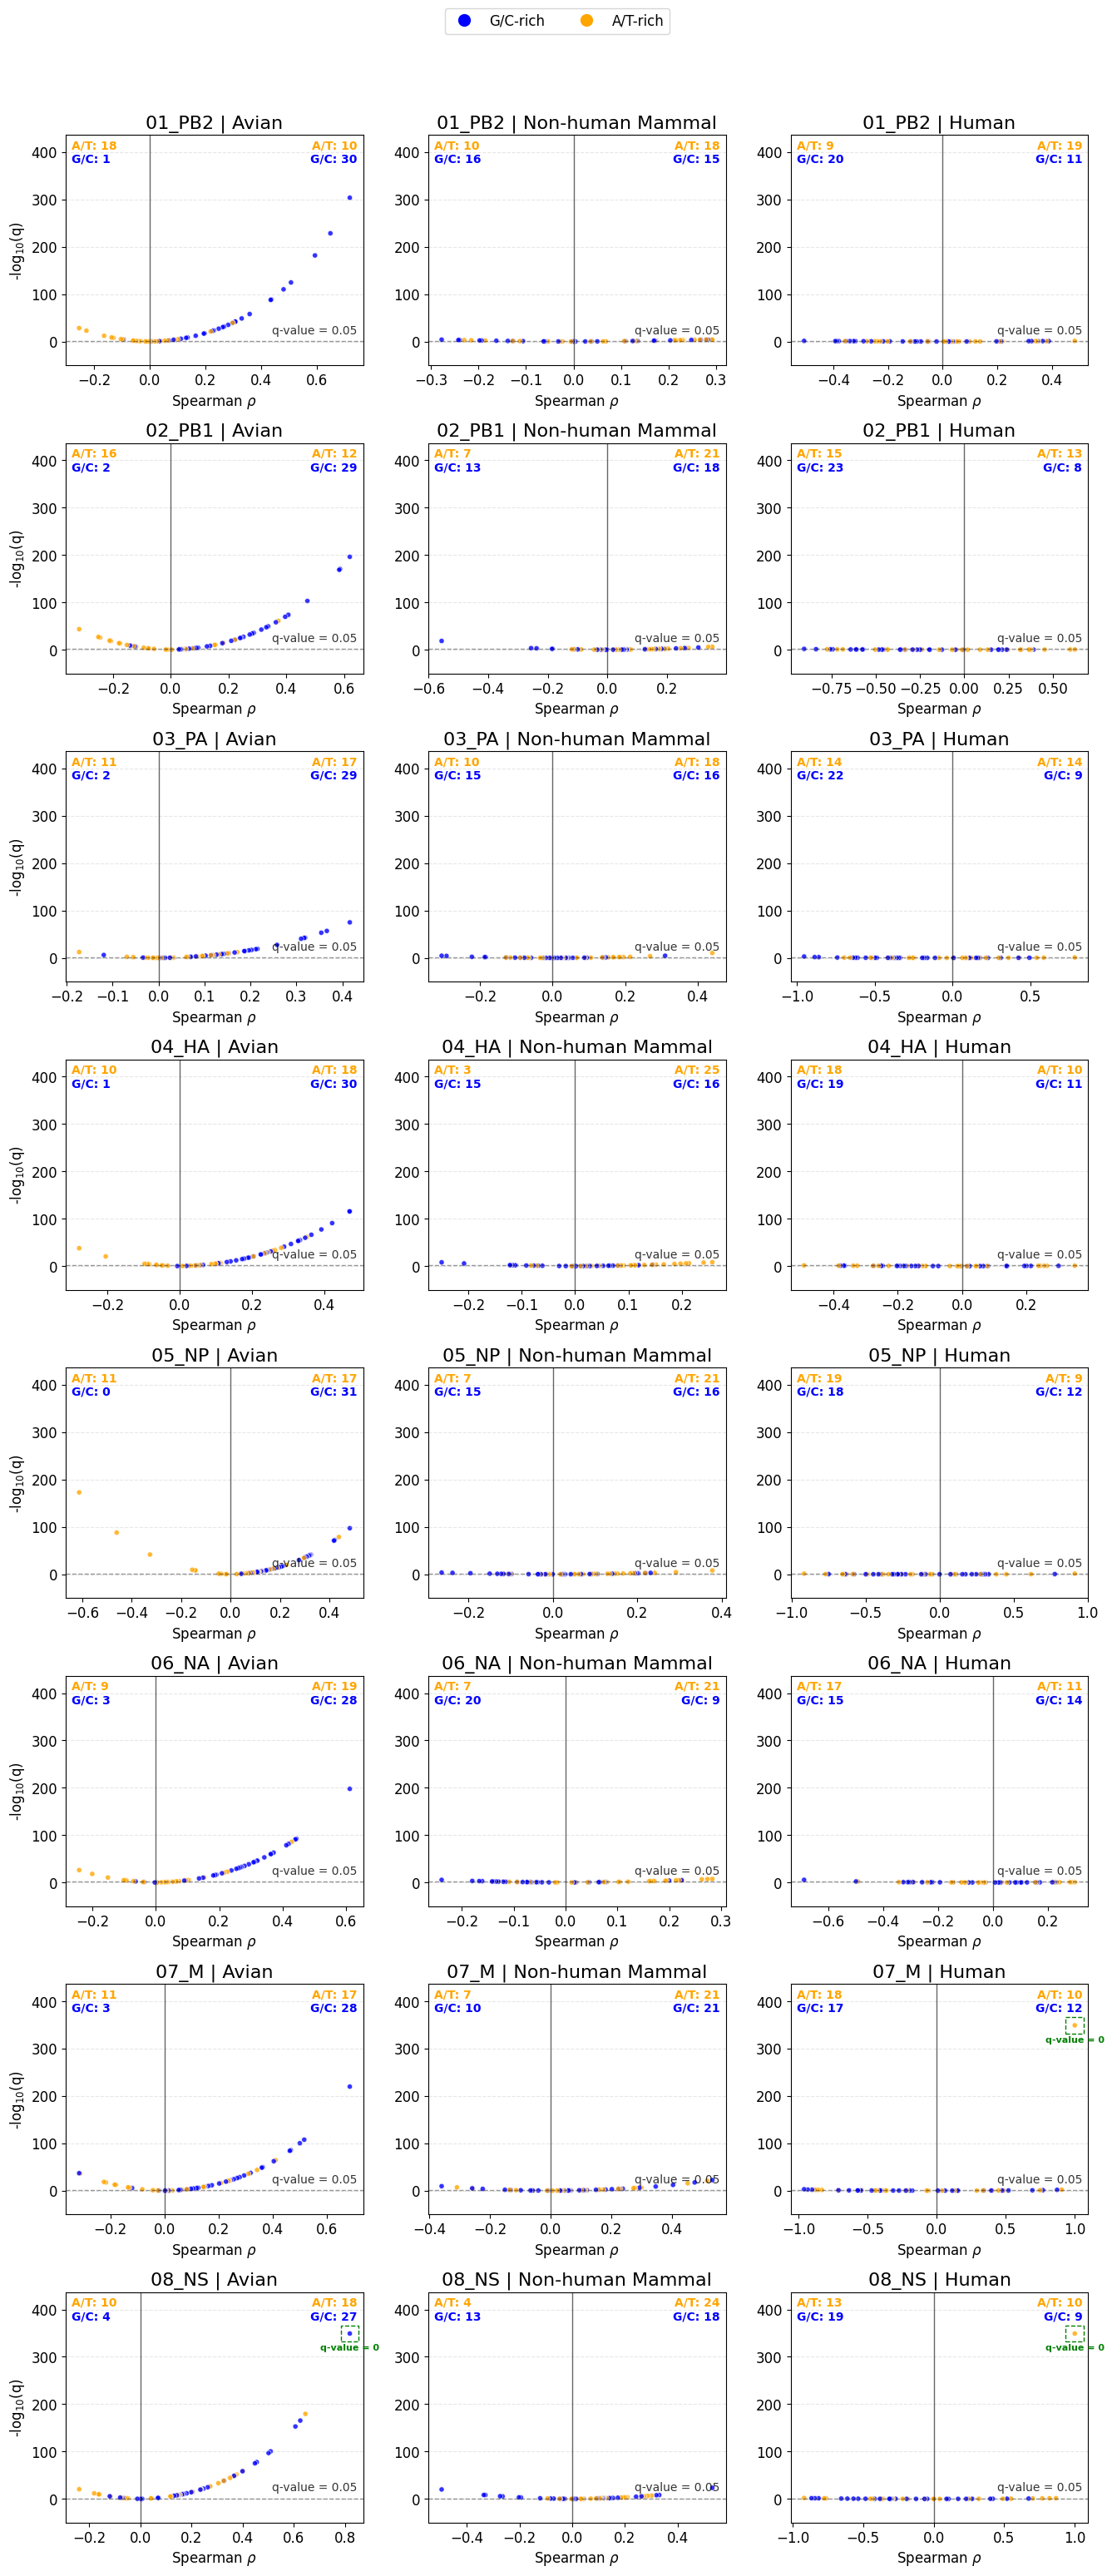

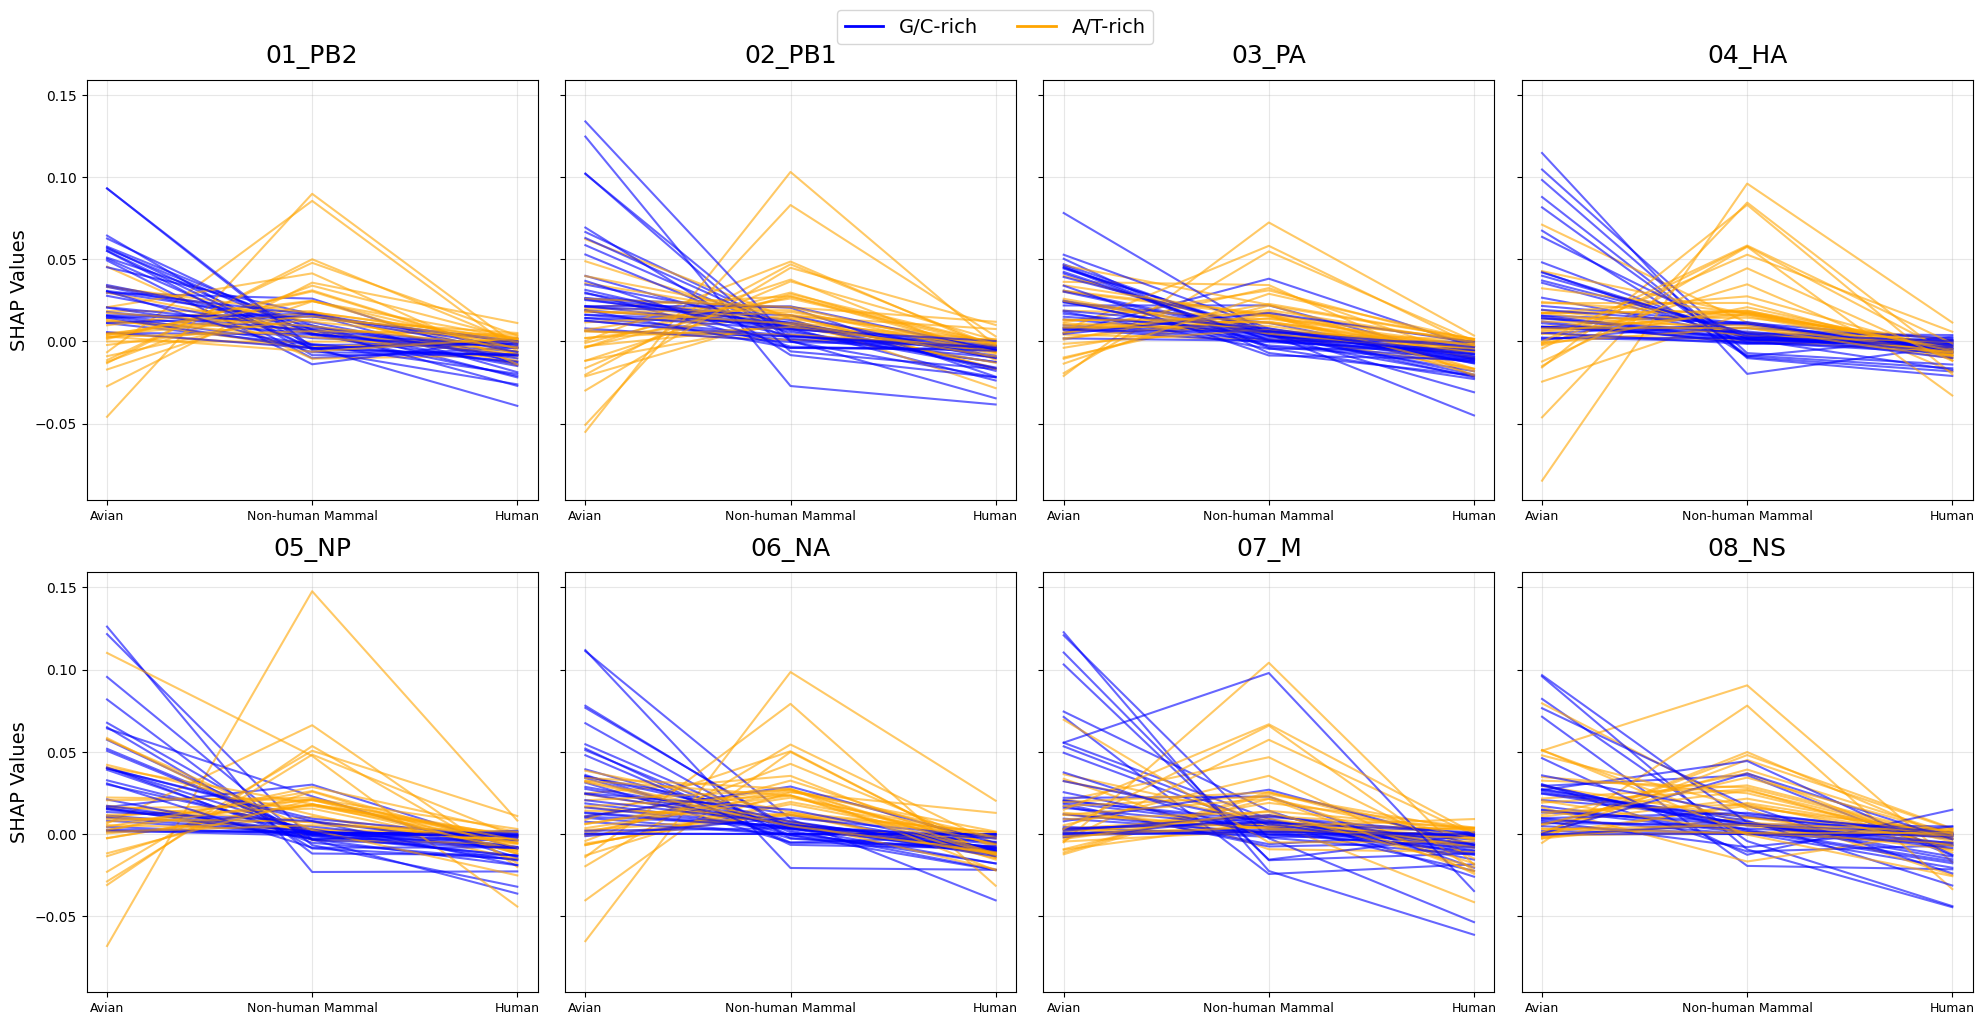

In [6]:
corr_dfs = {}
trend_dfs = {}
for seg in segments:
    print("="*50)
    print(f"Processing segment {seg}")
    print("="*50)
    
    shap_df_post2020, rscu_df_post2020, codon_cols  = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Post2020_', file_pattern_rscu ='All_True_Label_Post2020_', datatype= 'post2020', verbose=False)
    shap_df_pre2020,  rscu_df_pre2020, _            = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Training_', file_pattern_rscu ='All_True_Label_Training_', datatype= 'pre2020', verbose=False)
    shap_df = pd.concat([shap_df_pre2020, shap_df_post2020], ignore_index=True)
    rscu_df = pd.concat([rscu_df_pre2020, rscu_df_post2020], ignore_index=True)
    codon_categories = codon_category_map(codon_cols)
    
    codon_categories = codon_category_map(codon_cols)
    shap_df_subtype = shap_df[shap_df['subtype'].astype(str).isin(['H3N8', 'H7N7'])]
    rscu_df_subtype = rscu_df[rscu_df['subtype'].astype(str).isin(['H3N8', 'H7N7'])]
    
    print (shap_df_subtype.shape, rscu_df_subtype.shape)
    corr_df = compute_rscu_shap_correlations(shap_df_subtype, rscu_df_subtype, codon_cols, codon_categories, method='spearman')
    corr_dfs[seg]= corr_df
    trend_df = analyze_codon_shap_trends(shap_df_subtype, codon_cols, codon_categories)
    trend_dfs[seg] = trend_df
volcano_plot_grid(corr_dfs, codon_categories, save_path=f"../../results/Other_Figs/rscu_shap_Correlation_spearman_H3N8_H7N7.png", grid_shape=(8, 3))
codon_trajectory_plot_grid(trend_dfs, codon_categories, save_path=f"../../results/Supplementary_Figure_S11_Trajectories_H3N8_H7N7.png")